### Задание 8. 

In [149]:
import numpy as np
import matplotlib.pyplot as plt

In [151]:
P = {'A': [0.229077  , 0.2482066 , 0.3830703 , 0.1396461],
       'C': [0.25291181, 0.36173045, 0.0921797 , 0.29317804],
       'G': [0.20027913, 0.29134682, 0.34263782, 0.16573622],
       'T': [0.13647521, 0.27736868, 0.39567992, 0.19047619]}

In [153]:
def generate_sequence(P, length, start_state):
    nucs = ['A', 'C', 'G', 'T']
    seq = [start_state]
    current = start_state
    for _ in range(length - 1):
        probs = P[current]
        next_nuc = np.random.choice(nucs, p=probs)
        seq.append(next_nuc)
        current = next_nuc
    
    return ''.join(seq)

In [155]:
seqs = []
for _ in range(10):
    start_state = np.random.choice(['A', 'C', 'G', 'T'])
    seqs.append(generate_sequence(P, 1000, start_state))

In [157]:
P_emp = np.zeros((4,4), dtype=float)
nuc_to_idx = {'A':0, 'C':1, 'G':2, 'T':3}

for seq in seqs:
    counts = np.zeros((4,4))
    for k in range(len(seq)-1):
        i = nuc_to_idx[seq[k]]
        j = nuc_to_idx[seq[k+1]]
        counts[i,j] += 1
    P_emp += counts / (len(seq)-1)

for i in range(4):
    P_emp[i] = P_emp[i]/np.sum(P_emp[i])

In [159]:
P_emp

array([[0.21052632, 0.25764411, 0.39548872, 0.13634085],
       [0.24332344, 0.36894164, 0.10089021, 0.28684471],
       [0.19309638, 0.29015721, 0.34620643, 0.17053999],
       [0.13261297, 0.27111984, 0.40127701, 0.19499018]])

In [161]:
P = [[0.229077  , 0.2482066 , 0.3830703 , 0.1396461],
    [0.25291181, 0.36173045, 0.0921797 , 0.29317804],
    [0.20027913, 0.29134682, 0.34263782, 0.16573622],
    [0.13647521, 0.27736868, 0.39567992, 0.19047619]]

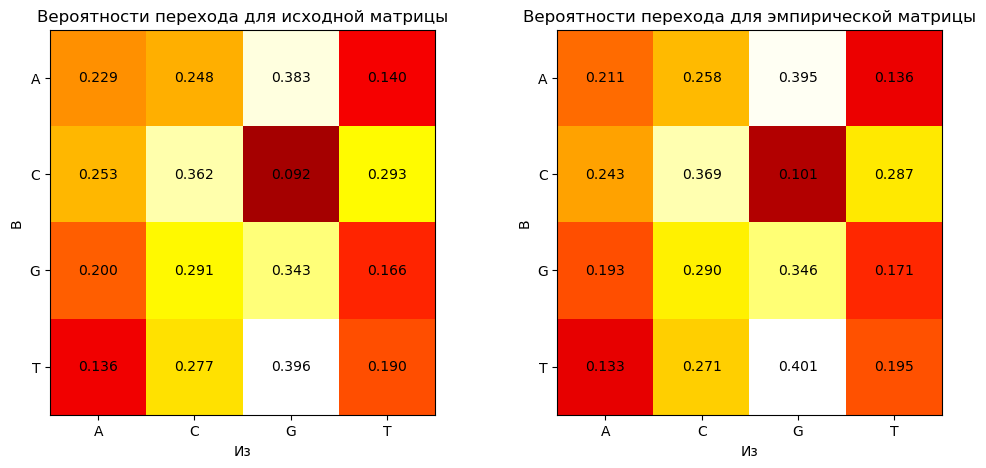

In [171]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(P, cmap='hot', interpolation='nearest', vmin=0, vmax=np.max(P))
axes[0].set_title('Вероятности перехода для исходной матрицы')
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
axes[0].set_xticklabels(['A','C','G','T'])
axes[0].set_yticklabels(['A','C','G','T'])
axes[0].set_xlabel('Из')
axes[0].set_ylabel('В')
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f'{P[i][j]:.3f}', ha='center', va='center', color='black')

im1 = axes[1].imshow(P_emp, cmap='hot', interpolation='nearest', vmin=0, vmax=np.max(P_emp))
axes[1].set_title('Вероятности перехода для эмпирической матрицы')
axes[1].set_xticks(range(4))
axes[1].set_yticks(range(4))
axes[1].set_xticklabels(['A','C','G','T'])
axes[1].set_yticklabels(['A','C','G','T'])
axes[1].set_xlabel('Из')
axes[1].set_ylabel('В')
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, f'{P_emp[i][j]:.3f}', ha='center', va='center', color='black')

**Вывод:** обе матрицы достаточно похожи, но наблюдаются небольшие отличия. Возможно, это связано с недостаточным количеством последовательностей или тем, что первые нуклеотиды в последовательностях выбирались рандомно с равномерным распределением. 